cnn code


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0
# reshape for CNN
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Capture history for plotting
history = model.fit(X_train_cnn, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.1)

test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("Test accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9473 - loss: 0.1749 - val_accuracy: 0.9823 - val_loss: 0.0644
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9839 - loss: 0.0527 - val_accuracy: 0.9870 - val_loss: 0.0463
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9881 - loss: 0.0371 - val_accuracy: 0.9873 - val_loss: 0.0453
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9916 - loss: 0.0267 - val_accuracy: 0.9892 - val_loss: 0.0400
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9934 - loss: 0.0204 - val_accuracy: 0.9893 - val_loss: 0.0468
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9944 - loss: 0.0162 - val_accuracy: 0.9903 - val_loss: 0.0393
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9907 - val_loss: 0.0390
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9968 - loss: 0.0095 - val_accuracy: 0.

#task 1)

#1)accuracy vs loss

#2)add confusion matrix

#3)2nd network  with only one convolutional function/layer , 1 pooling , 2 dense layer

#4) 3rd network with one convolutional layer , 1 pooling , one dense layer

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


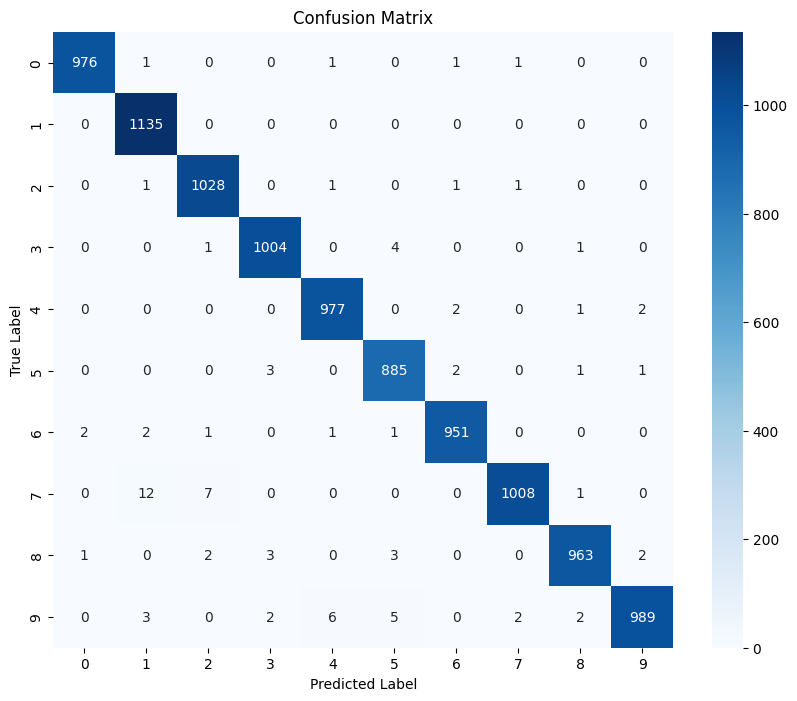

In [ ]:
# 2) Add Confusion Matrix
y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# 3) 2nd network: 1 conv, 1 pooling, 2 dense layers
model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("--- Model 2 Summary ---")
model2.summary()

model2.fit(X_train_cnn, y_train, epochs=5, batch_size=64, validation_split=0.1)

--- Model 2 Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9370 - loss: 0.2198 - val_accuracy: 0.9793 - val_loss: 0.0794
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9786 - loss: 0.0734 - val_accuracy: 0.9832 - val_loss: 0.0636
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9852 - loss: 0.0502 - val_accuracy: 0.9833 - val_loss: 0.0560
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9883 - loss: 0.0383 - val_accuracy: 0.9867 - val_loss: 0.0493
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9867 - val_loss: 0.0492


In [ ]:
# 4) 3rd network: 1 conv, 1 pooling, 1 dense layer
model3 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(10, activation='softmax')
])

model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("--- Model 3 Summary ---")
model3.summary()

model3.fit(X_train_cnn, y_train, epochs=5, batch_size=64, validation_split=0.1)

--- Model 3 Summary ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9153 - loss: 0.3016 - val_accuracy: 0.9675 - val_loss: 0.1185
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9685 - loss: 0.1114 - val_accuracy: 0.9795 - val_loss: 0.0778
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9777 - loss: 0.0788 - val_accuracy: 0.9813 - val_loss: 0.0655
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9816 - loss: 0.0634 - val_accuracy: 0.9828 - val_loss: 0.0648
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9842 - loss: 0.0532 - val_accuracy: 0.9842 - val_loss: 0.0569


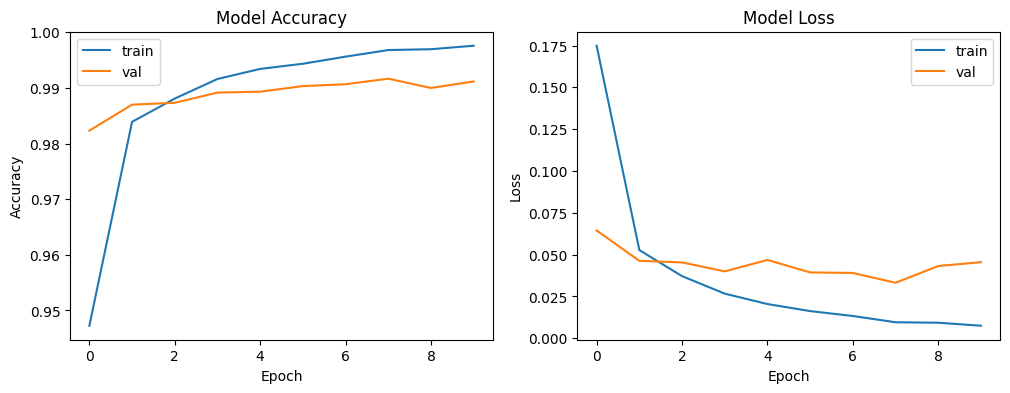

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1) Accuracy vs Loss Plot
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    plt.show()

# Call the function for the first model
plot_history(history)

testing with handwritten 0-9

Please upload your handwritten images (0-9)...


Saving WhatsApp Image 2026-03-15 at 5.40.02 PM.jpeg to WhatsApp Image 2026-03-15 at 5.40.02 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.40.23 PM.jpeg to WhatsApp Image 2026-03-15 at 5.40.23 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.40.37 PM.jpeg to WhatsApp Image 2026-03-15 at 5.40.37 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.40.52 PM.jpeg to WhatsApp Image 2026-03-15 at 5.40.52 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.41.05 PM.jpeg to WhatsApp Image 2026-03-15 at 5.41.05 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.41.43 PM.jpeg to WhatsApp Image 2026-03-15 at 5.41.43 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.42.10 PM.jpeg to WhatsApp Image 2026-03-15 at 5.42.10 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.42.39 PM.jpeg to WhatsApp Image 2026-03-15 at 5.42.39 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.43.12 PM.jpeg to WhatsApp Image 2026-03-15 at 5.43.12 PM.jpeg
Saving WhatsApp Image 2026-03-15 at 5.43.22 PM.jpeg to WhatsApp Image 2026-03-15 at 5.43.22 PM.jpeg


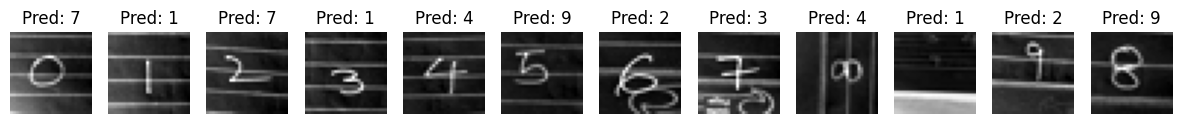

In [ ]:
from google.colab import files
import cv2
from PIL import Image
import io

# Upload images from your desktop
print("Please upload your handwritten images (0-9)...")
uploaded = files.upload()

plt.figure(figsize=(15, 5))

for i, filename in enumerate(uploaded.keys()):
    # Read and preprocess the image
    image_data = uploaded[filename]
    img = Image.open(io.BytesIO(image_data)).convert('L') # Convert to grayscale
    img = img.resize((28, 28)) # Resize to 28x28

    # Convert to array and normalize
    img_array = np.array(img)

    # MNIST images have black backgrounds and white digits.
    # If your drawing is black ink on white paper, we need to invert it.
    # We assume inversion is needed if the center pixel is brighter than the corner.
    if img_array[0,0] > 127:
        img_array = 255 - img_array

    img_array = img_array / 255.0
    img_input = img_array.reshape(1, 28, 28, 1)

    # Predict using the first model
    prediction = model.predict(img_input)
    predicted_digit = np.argmax(prediction)

    # Plot result
    plt.subplot(1, len(uploaded), i + 1)
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Pred: {predicted_digit}")
    plt.axis('off')

plt.show()